In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.transforms.functional import resize as torch_resize


# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [214]:
# Device setup: use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [215]:
metadata_train_csv = 'processed_metadata_train.csv'
metadata_test_csv = 'processed_metadata_test.csv'
train_df = pd.read_csv(metadata_train_csv)
test_df = pd.read_csv(metadata_test_csv)

In [216]:
train_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_1u4I3V3fhRDDfLHRbDwO9w,drink,1u4I3V3fhRDDfLHRbDwO9w,False
1,drink_2_kCob6wOKqwm6hXQ-WLYCOA,drink,kCob6wOKqwm6hXQ-WLYCOA,False


In [217]:
test_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_8VfJq1vTpMh6IMKhtbsqHg,drink,8VfJq1vTpMh6IMKhtbsqHg,False
1,drink_2_3LGq6soWgPCWeVqaJCqCnw,drink,3LGq6soWgPCWeVqaJCqCnw,False


In [218]:
print("Train labels:", train_df['label'].unique())
print("Test labels:", test_df['label'].unique())
print(train_df['label'].value_counts())

Train labels: ['drink' 'food' 'inside' 'menu' 'outside']
Test labels: ['drink' 'food' 'inside' 'menu' 'outside']
label
drink      5000
food       5000
inside     5000
menu       5000
outside    5000
Name: count, dtype: int64


In [219]:
train_img_dir = 'original_photos_train'
test_img_dir = 'original_photos_test'

In [220]:
## Multi-Class Dataset
class MultiClassDataset(Dataset):
    def __init__(self, meta_csv, img_dir, img_size=(64, 64), sample_n=None):
        df = pd.read_csv(meta_csv)
        # Clean column names
        df.columns = df.columns.str.strip().str.lower()
        # Exclude 'menu' class and reset index
        df = df[df['label'] != 'menu'].reset_index(drop=True)
        # Group-wise sampling: keep 'label' column after sampling
        if sample_n is not None:
            df = (
                df.groupby('label', group_keys=False)
                .apply(lambda x: x.sample(min(len(x), sample_n), random_state=42))
                .reset_index(drop=True)
            )
        # Final check for 'label' column
        if 'label' not in df.columns:
            raise ValueError("Column 'label' is missing after sampling. Columns: {}".format(df.columns.tolist()))

        self.df = df
        self.labels = sorted(df['label'].unique())
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize(img_size),   # <---- added resize here
            transforms.ToTensor(),
        ])
        self.label_to_idx = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['original_photo_id'] + '.jpg')
        try:
            with Image.open(img_path) as img:
                img = img.convert('RGB')
                img = self.transform(img)
        except Exception as e:
            print(f"Error loading image: {img_path} | Exception: {e}")
            img = torch.zeros(3, self.img_size[0], self.img_size[1])
        label = self.label_to_idx[row['label']]
        return img, label

In [ ]:
# Data Loader
def create_loaders(metadata_train_csv, train_img_dir, metadata_test_csv, test_img_dir, batch_size=128, img_size=(64, 64), sample_n=None):
    train_ds = MultiClassDataset(metadata_train_csv, train_img_dir, img_size, sample_n)
    test_ds = MultiClassDataset(metadata_test_csv, test_img_dir, img_size, sample_n)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, test_loader, train_ds.labels

In [ ]:
#Hyperparameter
batch_size = 192
img_size = (64, 64)
latent_dim = 64
epochs = 200
sample_n = 1000 # None for full dataset

In [223]:
# Create loaders and get dataset
train_loader, test_loader, labels = create_loaders(
    metadata_train_csv, train_img_dir,
    metadata_test_csv, test_img_dir,
    batch_size, img_size, sample_n
)
train_ds = train_loader.dataset

In [ ]:
#VAE BASE MODEL DEFINITION( ECODER, DECORDER, AUTOENCODER)
# VAE model_1 definition
class VAE(nn.Module):
    def __init__(self, latent_dim=64, img_channels=3, img_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_channels = img_channels
        self.img_size = img_size
        self.feature_dim = 128 * (img_size // 8) * (img_size // 8)
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(self.feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.feature_dim, latent_dim)
        # Decoder
        self.decoder_input = nn.Linear(latent_dim, self.feature_dim)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, img_size // 8, img_size // 8)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 4, 2, 1), nn.Sigmoid()
        )
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z):
        x = self.decoder_input(z)
        x = self.decoder(x)
        return x
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [ ]:
 # MODEL INSTANTIATION
model_1= VAE(latent_dim=latent_dim, img_channels=3, img_size=img_size[0]).to(device)
print(f"model_1 parameters: {sum(p.numel() for p in model_1.parameters()):,}")

model_1 parameters: 1,912,899


In [ ]:
# MODEL SUMMARY OF ENCORDER, DECODER AND AUTO ENCODER
def print_model_1_summaries(model_1, img_channels=3, img_size=64):
    dummy = torch.zeros(1, img_channels, img_size, img_size).to(next(model_1.parameters()).device)
    print("\nEncoder Summary:")
    print(model_1.encoder)
    mu, logvar = model_1.encode(dummy)
    print(f"Encoder output shapes: mu {mu.shape}, logvar {logvar.shape}")

    print("\nDecoder Summary:")
    print(model_1.decoder)
    z = torch.zeros(1, model_1.latent_dim).to(dummy.device)
    dec_out = model_1.decode(z)
    print(f"Decoder output shape: {dec_out.shape}")

    print("\nFull Autoencoder Summary:")
    recon, mu, logvar = model_1(dummy)
    print(f"Input shape: {dummy.shape}, Recon shape: {recon.shape}")

# Print summary for a quick check (optional, can comment out)
print_model_1_summaries(model_1, img_channels=3, img_size=img_size[0])


Encoder Summary:
Sequential(
  (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Flatten(start_dim=1, end_dim=-1)
)
Encoder output shapes: mu torch.Size([1, 64]), logvar torch.Size([1, 64])

Decoder Summary:
Sequential(
  (0): Unflatten(dim=1, unflattened_size=(128, 8, 8))
  (1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2

In [227]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


In [ ]:
def train_vae(model_1, train_loader, test_loader, epochs=200, lr=5e-5, device=None, beta_anneal=True):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    optimizer = torch.optim.Adam(model_1.parameters(), lr=lr)
    train_losses, test_losses = [], []
    kl_losses, kl_test_losses = [], []
    for epoch in range(epochs):
        # KL annealing (linear ramp up beta to 1.0 in first 150 epochs)
        if beta_anneal:
            beta = min(1.0, epoch / 150)
        else:
            beta = 0.2

        model_1.train()
        train_loss = 0
        kl_loss_epoch = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model_1(data)
            loss, _, kl_loss = vae_loss_function(recon, data, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            kl_loss_epoch += kl_loss.item()
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_kl_loss = kl_loss_epoch / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        kl_losses.append(avg_kl_loss)

        # Test loss
        model_1.eval()
        test_loss = 0
        kl_test_loss_epoch = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon, mu, logvar = model_1(data)
                loss, _, kl_loss = vae_loss_function(recon, data, mu, logvar, beta=beta)
                test_loss += loss.item()
                kl_test_loss_epoch += kl_loss.item()
        avg_test_loss = test_loss / len(test_loader.dataset)
        avg_kl_test_loss = kl_test_loss_epoch / len(test_loader.dataset)
        test_losses.append(avg_test_loss)
        kl_test_losses.append(avg_kl_test_loss)

        if (epoch + 1) % 20 == 0 or (epoch + 1) == epochs:
            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.2f}, KL Loss = {avg_kl_loss:.2f}, Test Loss = {avg_test_loss:.2f}, KL Test Loss = {avg_kl_test_loss:.2f}, Beta = {beta:.3f}")
    return model_1, train_losses, test_losses, kl_losses, kl_test_losses


Epoch 20: Train Loss = 7045.34, KL Loss = 179.67, Test Loss = 7045.87, KL Test Loss = 180.14, Beta = 0.127
Epoch 40: Train Loss = 6800.09, KL Loss = 167.03, Test Loss = 6823.59, KL Test Loss = 165.83, Beta = 0.260
Epoch 60: Train Loss = 6743.52, KL Loss = 152.75, Test Loss = 6775.87, KL Test Loss = 153.24, Beta = 0.393
Epoch 80: Train Loss = 6733.10, KL Loss = 139.47, Test Loss = 6765.12, KL Test Loss = 141.11, Beta = 0.527
Epoch 100: Train Loss = 6730.30, KL Loss = 129.82, Test Loss = 6766.33, KL Test Loss = 130.06, Beta = 0.660
Epoch 120: Train Loss = 6734.50, KL Loss = 122.25, Test Loss = 6773.28, KL Test Loss = 121.40, Beta = 0.793
Epoch 140: Train Loss = 6743.54, KL Loss = 116.23, Test Loss = 6784.08, KL Test Loss = 115.05, Beta = 0.927
Epoch 160: Train Loss = 6742.15, KL Loss = 112.82, Test Loss = 6787.35, KL Test Loss = 113.01, Beta = 1.000
Epoch 180: Train Loss = 6733.73, KL Loss = 112.07, Test Loss = 6785.07, KL Test Loss = 113.48, Beta = 1.000
Epoch 200: Train Loss = 6729.76,

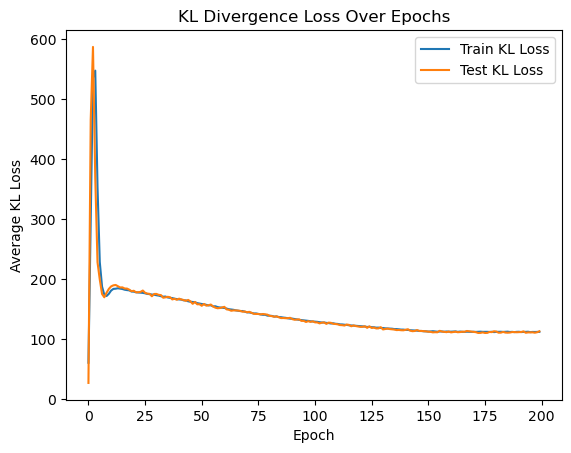

In [ ]:
# Training model_1
model_1, train_losses, test_losses, kl_losses, kl_test_losses = train_vae(
    model_1, train_loader, test_loader, epochs=200, lr=5e-5, device=device, beta_anneal=True
)

#plot the KL divergence losses:
plt.plot(kl_losses, label='Train KL Loss')
plt.plot(kl_test_losses, label='Test KL Loss')
plt.xlabel('Epoch')
plt.ylabel('Average KL Loss')
plt.title('KL Divergence Loss Over Epochs')
plt.legend()
plt.show()


In [230]:
## IMAGE RECONSTRUCTION
label_names = train_ds.labels
n_labels = len(label_names)

## Reconstruction

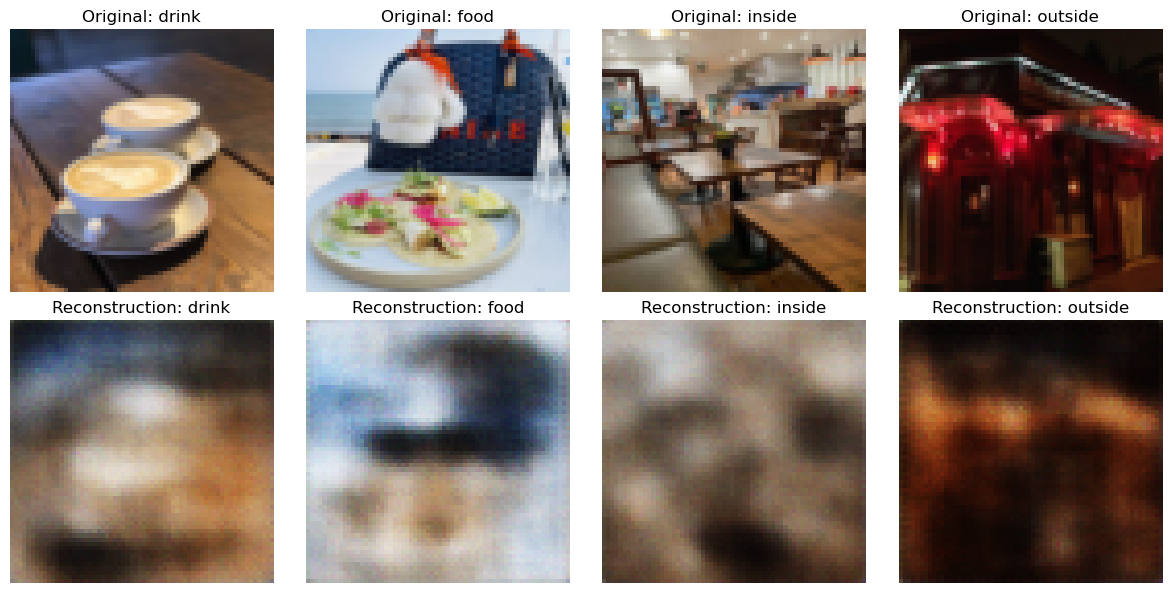

In [231]:
# Set model_1 to evaluation mode for inference
model_1.eval()

# Find and visualize one example per class
found = {label_idx: None for label_idx in range(len(label_names))}

for imgs, labels in test_loader:
    for i, label_idx in enumerate(labels):
        label_idx = int(label_idx)
        if found[label_idx] is None:
            found[label_idx] = (imgs[i], label_idx)
    if all(v is not None for v in found.values()):
        break

fig, axes = plt.subplots(2, n_labels, figsize=(3 * n_labels, 6))
for i, label in enumerate(label_names):
    if found[i] is not None:
        img_tensor, label_idx = found[i]
        img_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            recon_img, _, _ = model_1(img_tensor)
        # Original
        axes[0, i].imshow(np.transpose(img_tensor.cpu().squeeze().numpy(), (1, 2, 0)))
        axes[0, i].set_title(f"Original: {label}")
        axes[0, i].axis('off')
        # Reconstruction
        axes[1, i].imshow(np.transpose(recon_img.cpu().squeeze().numpy(), (1, 2, 0)))
        axes[1, i].set_title(f"Reconstruction: {label}")
        axes[1, i].axis('off')
    else:
        axes[0, i].set_visible(False)
        axes[1, i].set_visible(False)

plt.tight_layout()
plt.show()

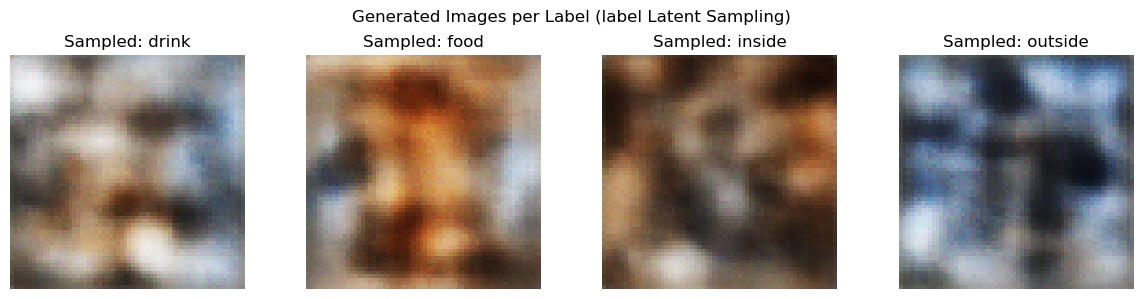

In [232]:

# Using Latent Sampling to generate new images per Label
# Step 1: Collect mu's for each class
class_mus = {i: [] for i in range(len(label_names))}
for imgs, labels in test_loader:
    imgs = imgs.to(device)
    with torch.no_grad():
        mus, _ = model_1.encode(imgs)
    for mu, label in zip(mus, labels):
        class_mus[int(label)].append(mu.cpu().numpy())
for i in class_mus:
    class_mus[i] = np.stack(class_mus[i], axis=0)

# Step 2: For each class, get mean and std of mus
class_mean_std = {i: (np.mean(class_mus[i], axis=0), np.std(class_mus[i], axis=0)) for i in class_mus}

# Step 3: Generate one new image per class using class mean and std
fig, axes = plt.subplots(1, len(label_names), figsize=(3*len(label_names), 3))
for i, label in enumerate(label_names):
    mean, std = class_mean_std[i]
    z = np.random.normal(mean, std).astype(np.float32)
    z = torch.from_numpy(z).unsqueeze(0).to(device)
    with torch.no_grad():
        img = model_1.decode(z)
    axes[i].imshow(np.transpose(img.cpu().squeeze().numpy(), (1, 2, 0)))
    axes[i].set_title(f"Sampled: {label}")
    axes[i].axis('off')
plt.suptitle("Generated Images per Label (label Latent Sampling)")
plt.tight_layout()
plt.show()

In [233]:
## Evaluating model using Inception Score and Frechet Inception Distance using a pretrained model
# A. Generating  a Batch of Images from already Trained VAE model
# gen_imgs--calling VAE model

# Set model to evaluation mode
model_1.eval()

# Number of images to generate for FID/IS
n_gen = 1000
z = torch.randn(n_gen, latent_dim).to(next(model_1.parameters()).device)

with torch.no_grad():
    gen_imgs = model_1.decode(z).cpu().numpy()
# NCHW → NHWC for metric computation and visualization
gen_imgs = np.transpose(gen_imgs, (0, 2, 3, 1))
print(f"Generated {gen_imgs.shape[0]} images for FID/IS evaluation.")

# B. Collecting and Resizing Images from generated VAE IMAGES and Test SET
# Collect images (same number as test, n_gen)
# real_imgs saving test set
real_imgs = []
for imgs, _ in test_loader:
    for img in imgs:
        real_imgs.append(img.numpy().transpose(1, 2, 0))  # CHW to HWC
        if len(real_imgs) >= n_gen:
            break
    if len(real_imgs) >= n_gen:
        break
real_imgs = np.array(real_imgs[:n_gen])
print(f"Collected {real_imgs.shape[0]} real images for FID/IS evaluation.")

Generated 1000 images for FID/IS evaluation.
Collected 1000 real images for FID/IS evaluation.


In [234]:
# Upsample both generated and test set images to 299x299 for InceptionV3

def upsample_images(image_array, size=(299, 299)):
    upsampled = []
    for img in image_array:
        # Convert HWC numpy to CHW torch tensor, add batch
        img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).float()
        img_tensor = F.interpolate(img_tensor, size=size, mode='bilinear', align_corners=False)
        img_np = img_tensor.squeeze(0).permute(1,2,0).numpy()
        upsampled.append(img_np)
    return np.stack(upsampled)

gen_imgs_upsampled = upsample_images(gen_imgs)
real_imgs_upsampled = upsample_images(real_imgs)
print("Upsampled generated and test set images to 299x299 for InceptionV3.")

Upsampled generated and test set images to 299x299 for InceptionV3.


In [ ]:
# C. Extract Features with Pretrained InceptionV3
# Load pretrained InceptionV3 for feature extraction
inception = inception_v3(
    weights=Inception_V3_Weights.DEFAULT,
    transform_input=False,
    aux_logits=True
)
inception.fc = nn.Identity()
inception = inception.to(device)
inception.eval()

def get_inception_features(images, model_1, device, batch_size=32):
    features = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size]
            batch_tensor = torch.tensor(batch).permute(0, 3, 1, 2).to(device).float()  # NHWC to NCHW
            batch_tensor = (batch_tensor - 0.5) / 0.5  # normalize to [-1, 1]
            preds = model_1(batch_tensor)
            features.append(preds.cpu().numpy())
    features = np.concatenate(features, axis=0)
    return features

# gen_imgs_upsampled and real_imgs_upsampled numpy arrays of shape (N, H, W, C)
gen_features = get_inception_features(gen_imgs_upsampled, inception, device)
real_features = get_inception_features(real_imgs_upsampled, inception, device)

c:\Users\kauth\OneDrive\Desktop\Loyalist College\CV\Image_generator_model\cv2_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kauth\OneDrive\Desktop\Loyalist College\CV\Image_generator_model\cv2_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [236]:
# D. FID  METRIC CALCULATION
# FID calculation
def calculate_fid(mu1, sigma1, mu2, sigma2):
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

mu_gen, sigma_gen = gen_features.mean(axis=0), np.cov(gen_features, rowvar=False)
mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
fid_score = calculate_fid(mu_gen, sigma_gen, mu_real, sigma_real)
print(f"FID Score: {fid_score:.2f}")

FID Score: 276.27


In [237]:
# E. IS  METRIC CALCULATION
# Inception Score calculation
def calculate_inception_score(images, model_1, device, batch_size=128, splits=10):
    model_1_with_fc = inception_v3(pretrained=True, transform_input=False, aux_logits=True).to(device)
    model_1_with_fc.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size]
            batch_tensor = torch.tensor(batch).permute(0, 3, 1, 2).to(device).float()
            batch_tensor = (batch_tensor - 0.5) / 0.5
            logits = model_1_with_fc(batch_tensor)
            p = F.softmax(logits, dim=1).cpu().numpy()
            preds.append(p)
    preds = np.concatenate(preds, axis=0)
    scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * (N // splits): (k+1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores.append(np.exp(np.mean([np.sum(p * (np.log(p) - np.log(py))) for p in part])))
    return np.mean(scores), np.std(scores)

is_mean, is_std = calculate_inception_score(gen_imgs_upsampled, inception, device)
print(f"Inception Score: {is_mean:.2f} ± {is_std:.2f}")

Inception Score: 1.43 ± 0.03
